In [3]:
!pip install tensorflow
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [9]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


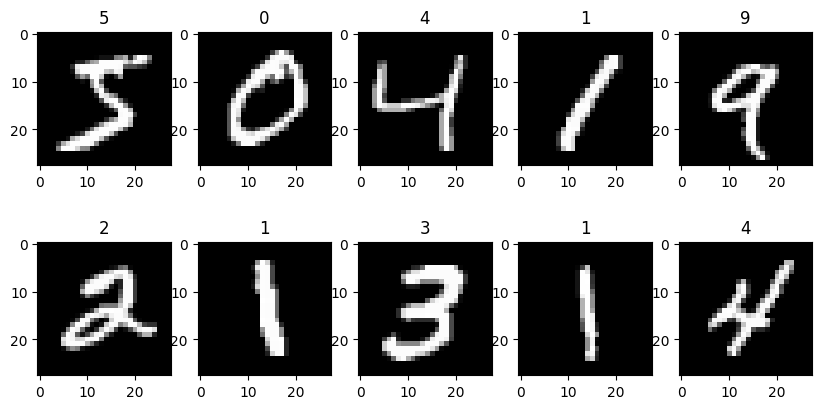

In [10]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.title(y_train[i])

plt.show()

In [11]:
X_train=X_train/255.0
X_test=X_test/255.0

In [12]:
print(X_train.shape)

(60000, 28, 28)


In [14]:
model=Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(10,activation='softmax'))

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history=model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9489 - loss: 0.1731 - val_accuracy: 0.9788 - val_loss: 0.0716
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9827 - loss: 0.0587 - val_accuracy: 0.9836 - val_loss: 0.0535
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9885 - loss: 0.0365 - val_accuracy: 0.9836 - val_loss: 0.0615
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9827 - val_loss: 0.0589
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9944 - loss: 0.0175 - val_accuracy: 0.9846 - val_loss: 0.0542


In [18]:
loss,accuracy=model.evaluate(
    X_test,
    y_test
)

print("Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9852 - loss: 0.0461
Accuracy: 0.9851999878883362


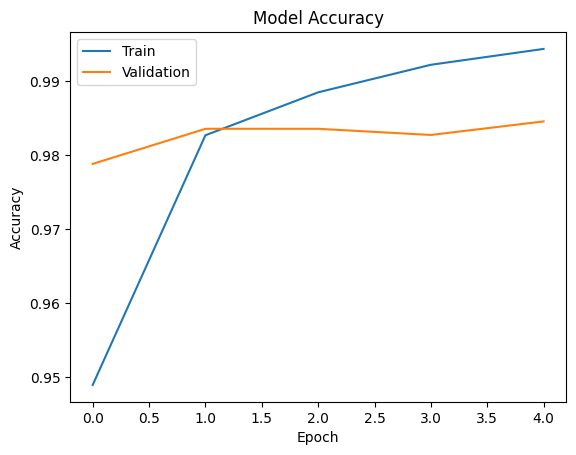

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(
    ['Train','Validation']
)

plt.show()

In [20]:
predictions=model.predict(X_test)

predicted=np.argmax(
    predictions,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


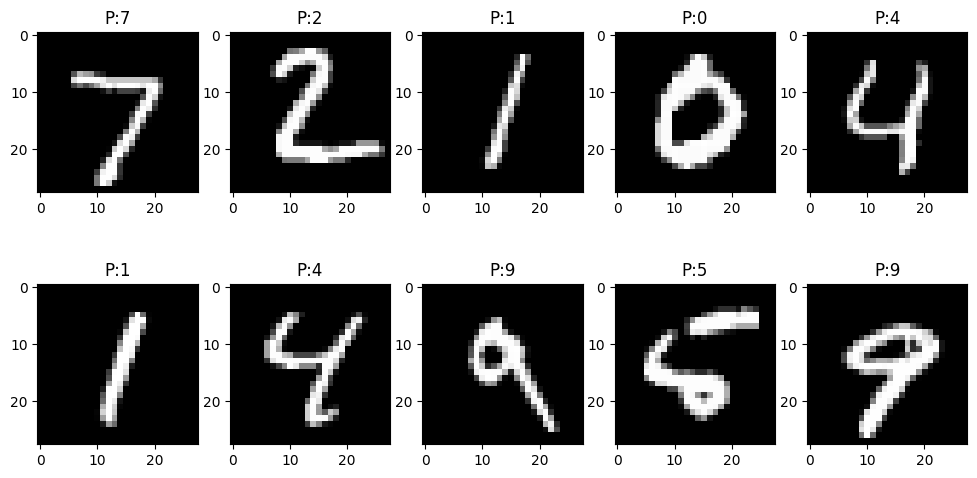

In [21]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"P:{predicted[i]}"
    )

plt.show()

In [22]:
print(
    classification_report(
        y_test,
        predicted
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.98      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.97      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



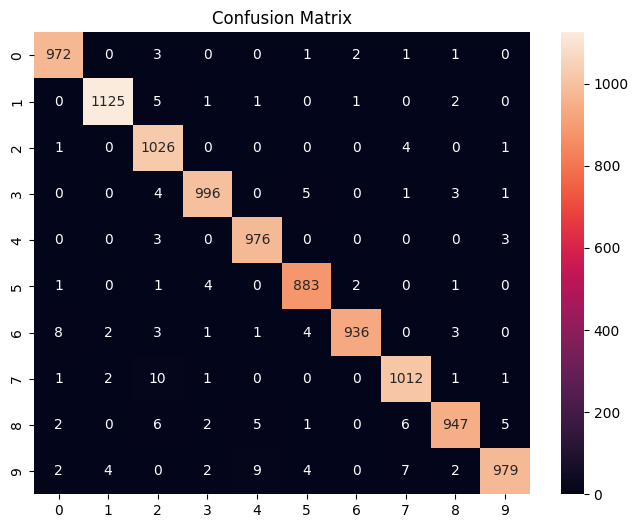

In [23]:
import seaborn as sns

cm=confusion_matrix(
    y_test,
    predicted
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()